In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
features = ['area', 'bedrooms', 'bathrooms']
X = df[features].values
y = df['price'].values.reshape(-1, 1)
X_normalized = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

Функція лінійної регресії у векторному вигляді:

In [3]:
def lin_regression(X, w):
    return X @ w

Функція обчислення втрат у векторному вигляді:

In [4]:
def ms_error(X, w):
    m = X.shape[0]
    predictions = lin_regression(X, w)
    errors =  predictions - y
    return (1 / (2 * m)) * np.sum(errors**2)

Функція градієнтного спуску на 1 крок:

In [5]:
def gradient_descent_step(X, w, y, lr):
    m = X.shape[0]
    predictions = lin_regression(X, w)
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return w - lr * gradient

In [6]:
X_final = np.insert(X_normalized, 0, 1, axis=1)
w_initial = np.zeros((X_final.shape[1], 1))

In [7]:
lr = 0.01
w_current = w_initial.copy()
epochs = 1000
history = []

for i in range(epochs):
    w_current = gradient_descent_step(X_final, w_current, y, lr)
    current_cost = ms_error(X_final, w_current)
    history.append(current_cost)

    if i % 100 == 0:
        cost = ms_error(X_final, w_current)
        print(f"Epoch {i}: Cost {cost}")

Epoch 0: Cost 12856932767146.535
Epoch 100: Cost 2442130541843.652
Epoch 200: Cost 1100952381760.1394
Epoch 300: Cost 923228125432.7102
Epoch 400: Cost 899349988814.1962
Epoch 500: Cost 896106962232.1779
Epoch 600: Cost 895659748870.8992
Epoch 700: Cost 895596362224.3958
Epoch 800: Cost 895586915096.59
Epoch 900: Cost 895585383053.9606


Аналітичне рішення:

In [8]:
w_analytical = np.linalg.inv(X_final.T @ X_final) @ X_final.T @ y

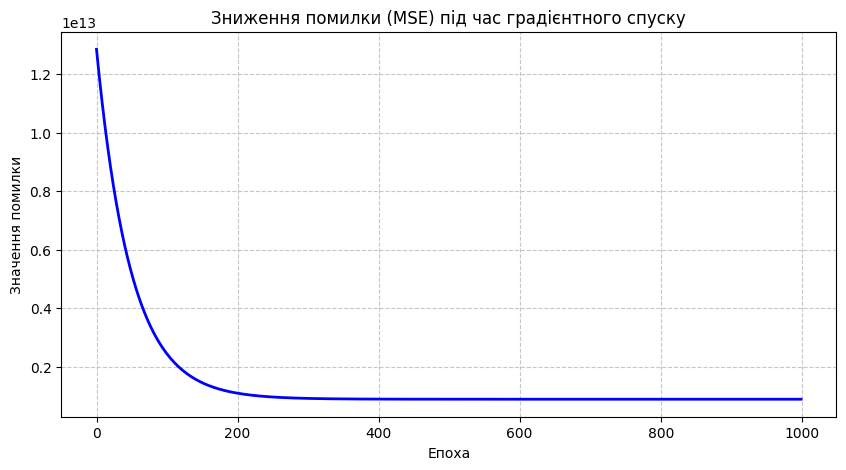

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history, color='blue', linewidth=2)
plt.title('Зниження помилки (MSE) під час градієнтного спуску')
plt.xlabel('Епоха')
plt.ylabel('Значення помилки')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

LinearRegression з бібліотеки scikit-learn:

In [10]:
model_sklearn = LinearRegression().fit(X_normalized, y)
w0_sklearn = model_sklearn.intercept_
weights_sklearn = model_sklearn.coef_
w_sklearn_full = np.insert(weights_sklearn, 0, w0_sklearn)

In [11]:
print(f"Градієнтний спуск:  {w_current.flatten()}")
print(f"Аналітичне рішення: {w_analytical.flatten()}")
print(f"Scikit-learn:       {w_sklearn_full}")

Градієнтний спуск:  [4766523.46205873  821199.26709864  300296.28560637  695515.99623791]
Аналітичне рішення: [4766729.24770642  821214.14349519  299983.57107963  695808.52272537]
Scikit-learn:       [4766729.24770642  821214.14349519  299983.57107963  695808.52272537]
